# Proyek Analisis Data : Earthquake, Seismic & Weather Dataset

Nama            : Anissa Salsabila  
NIM             : E1E124029  
Program Studi   : Teknik Informatika  
Fakultas        : Teknik  
Universitas     : Universitas Halu Oleo  

## Deskripsi Proyek

Proyek ini bertujuan untuk menganalisis kejadian gempa bumi berdasarkan karakteristik seismik, lokasi, waktu kejadian serta kondisi cuaca pada lokasi kejadian gempa.

Data diperoleh melalui integrasi tiga sumber API, yaitu:

1. USGS Earthquake API
2. EMSC Earthquake API
3. Open-Meteo Historical Weather API

Data dikumpulkan melalui pipeline ETL menggunakan Apache Airflow kemudian disimpan dan diintegrasikan dalam database MySQL.

Analisis dilakukan menggunakan Python melalui Jupyter Notebook.

# Menentukan Pertanyaan Bisnis

Berdasarkan dataset hasil integrasi data gempa dan cuaca pertanyaan bisnis
yang akan dijawab dalam analisis ini adalah :

1. Bagaimana karakteristik kejadian gempa berdasarkan magnitudo, kedalaman dan periode waktu?

2. Bagaimana hubungan antara magnitudo gempa dengan kedalaman serta kondisi
   cuaca pada lokasi kejadian gempa?

3. Wilayah atau lokasi mana yang memiliki konsentrasi kejadian gempa paling tinggi?

4. Seberapa baik model Machine Learning dapat memprediksi magnitudo gempa
   berdasarkan karakteristik lokasi, waktu, kedalaman dan kondisi cuaca?

# Import Semua Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sqlalchemy import create_engine, text

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    KFold
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Library berhasil diimpor.")

Matplotlib is building the font cache; this may take a moment.


Library berhasil diimpor.


# Versi Library

In [2]:
print("Pandas :", pd.__version__)
print("NumPy  :", np.__version__)
print("Seaborn:", sns.__version__)

Pandas : 3.0.6
NumPy  : 2.5.3
Seaborn: 0.13.2


# Gathering Data

In [3]:
MYSQL_USER = "root"
MYSQL_PASSWORD = "root"
MYSQL_HOST = "localhost"
MYSQL_PORT = "3306"
MYSQL_DATABASE = "earthquake_db"

MYSQL_URI = (
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}"
    f"@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
)

engine = create_engine(MYSQL_URI)

print("Koneksi database berhasil dibuat.")

Koneksi database berhasil dibuat.


# Mengecek Tabel Database

In [4]:
with engine.connect() as conn:
    tables = conn.execute(text("SHOW TABLES")).fetchall()

print("Tabel dalam database:")
for table in tables:
    print("-", table[0])

Tabel dalam database:
- earthquake_data
- earthquake_data_clean
- earthquake_seismic_integrated
- earthquake_weather_combined
- emsc_earthquakes
- openmeteo_weather
- usgs_earthquakes


# Memuat Dataset Utama

In [5]:
query = """
SELECT *
FROM earthquake_data
"""

df = pd.read_sql(query, engine)

print("Dataset berhasil dimuat.")
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Dataset berhasil dimuat.
Jumlah baris : 14397
Jumlah kolom : 28


# Melihat Data

In [6]:
df.head()

,usgs_id,event_time,magnitude,place,depth_km,longitude,latitude,mag_type,status,tsunami,emsc_id,emsc_event_time,emsc_magnitude,emsc_place,emsc_depth_km,emsc_longitude,emsc_latitude,emsc_mag_type,emsc_status,distance_km,magnitude_diff,event_date,weather_lat,weather_lon,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,surface_pressure_mean
0,ak025cmx1d48,2025-10-02 07:13:49,4.6,"57 km W of Karluk, Alaska",3.9,-155.4025,57.6300,ml,reviewed,0,20251002_0000111,2025-10-02 07:13:49,4.6,None,-4.1,-155.4223,57.6579,None,None,3.318562,0.0,2025-10-02,57.6,-155.4,9.4,6.7,42.9,1001.9
1,ak025cwudqus,2025-10-08 07:33:56,4.0,"52 km WNW of Nanwalek, Alaska",94.0,-152.8125,59.4909,ml,reviewed,0,20251008_0000106,2025-10-08 07:33:55,4.0,None,-99.0,-152.8084,59.4943,None,None,0.443277,0.0,2025-10-08,59.5,-152.8,10.7,0.0,18.5,1014.9
2,ak025d517bzx,2025-10-13 02:52:31,4.2,"30 km ESE of Kasilof, Alaska",45.9,-150.7827,60.2202,ml,reviewed,0,20251013_0000039,2025-10-13 02:52:30,4.4,None,-35.0,-150.7358,60.1803,None,None,5.138202,0.2,2025-10-13,60.2,-150.8,8.5,9.4,5.9,998.7
3,ak025d59j5t5,2025-10-13 16:51:17,4.1,"33 km E of Port Alsworth, Alaska",188.4,-153.7065,60.1979,ml,reviewed,0,20251013_0000227,2025-10-13 16:51:16,4.1,None,-185.5,-153.8712,60.2235,None,None,9.533415,0.0,2025-10-13,60.2,-153.7,5.2,12.8,9.1,950.8
4,ak025d8cqrw0,2025-10-15 03:30:45,4.0,"13 km SE of Glacier View, Alaska",27.0,-147.4562,61.7294,ml,reviewed,0,20251015_0000061,2025-10-15 03:30:45,4.0,None,-35.9,-147.5121,61.7506,None,None,3.770722,0.0,2025-10-15,61.7,-147.5,-4.9,0.6,8.3,850.6


# Melihat Data Terakhir

In [7]:
df.tail()

,usgs_id,event_time,magnitude,place,depth_km,longitude,latitude,mag_type,status,tsunami,emsc_id,emsc_event_time,emsc_magnitude,emsc_place,emsc_depth_km,emsc_longitude,emsc_latitude,emsc_mag_type,emsc_status,distance_km,magnitude_diff,event_date,weather_lat,weather_lon,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,surface_pressure_mean
14392,usd0015eeh,2026-08-17 16:08:45,4.30,"45 km NNE of Labuan Bajo, Indonesia",10.00,120.1127,-8.1551,mb,reviewed,0,20260817_0000536,2026-08-17 16:08:46,4.4,None,-11.0,120.2300,-8.2200,None,None,14.790278,0.10,2026-08-17,-8.2,120.1,27.0,0.2,28.3,1014.8
14393,usd0015ef3,2026-08-17 18:10:05,4.60,"156 km NNW of Pototano, Indonesia",492.20,117.1820,-7.0290,mb,reviewed,0,20260817_0000595,2026-08-17 18:10:06,4.6,None,-500.0,117.1200,-7.0751,None,None,8.549198,0.00,2026-08-17,-7.0,117.2,26.7,0.0,31.1,1014.2
14394,usd0015efc,2026-08-17 18:51:11,4.90,"30 km NE of Colonia, Micronesia",10.00,138.3349,9.6967,mww,reviewed,0,20260817_0000630,2026-08-17 18:51:10,4.9,None,-6.0,138.4008,9.6993,None,None,7.228811,0.00,2026-08-17,9.7,138.3,28.4,2.9,28.3,1011.1
14395,usd0015efp,2026-08-17 19:51:23,4.90,"214 km WSW of Longyearbyen, Svalbard and Jan M...",10.00,7.0817,77.5472,mww,reviewed,0,20260817_0000660,2026-08-17 19:51:23,4.8,None,-10.0,7.1095,77.5104,None,None,4.146066,0.10,2026-08-17,77.5,7.1,4.5,0.4,28.8,1014.6
14396,uu80127891,2026-01-22 14:49:21,4.65,"40 km S of Evanston, Wyoming",14.72,-110.8745,40.9105,ml,reviewed,0,20260122_0000265,2026-01-22 14:49:21,4.6,None,-10.0,-110.8423,40.9146,None,None,2.743940,0.05,2026-01-22,40.9,-110.9,-5.8,0.0,11.9,734.8


# Sample Dataset

In [8]:
df.sample(min(10, len(df)), random_state=42)

,usgs_id,event_time,magnitude,place,depth_km,longitude,latitude,mag_type,status,tsunami,emsc_id,emsc_event_time,emsc_magnitude,emsc_place,emsc_depth_km,emsc_longitude,emsc_latitude,emsc_mag_type,emsc_status,distance_km,magnitude_diff,event_date,weather_lat,weather_lon,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,surface_pressure_mean
13044,us7000t27r,2026-07-15 16:16:10,4.5,"180 km W of Abepura, Indonesia",10.000,139.0139,-2.7490,mb,reviewed,0,20260715_0000249,2026-07-15 16:16:11,4.4,None,-10.0,138.9000,-2.3500,None,None,46.135643,0.1,2026-07-15,-2.7,139.0,22.7,0.7,8.4,933.4
12598,us7000szus,2026-07-12 10:05:37,4.6,"88 km WSW of Gorontalo, Indonesia",150.599,122.3400,0.2049,mb,reviewed,0,20260712_0000126,2026-07-12 10:05:38,4.7,None,-160.0,122.3726,0.2239,None,None,4.195668,0.1,2026-07-12,0.2,122.3,28.2,0.0,30.5,1011.2
3753,us6000sa44,2026-02-19 04:40:38,4.1,western Xizang,10.000,81.7216,33.6048,mb,reviewed,0,20260219_0000073,2026-02-19 04:40:39,4.1,None,-10.0,81.6712,33.5947,None,None,4.801092,0.0,2026-02-19,33.6,81.7,-14.0,0.0,14.5,533.7
1662,us6000rmri,2025-11-11 12:03:09,4.5,"107 km E of Miyako, Japan",36.537,143.1874,39.6000,mb,reviewed,0,20251111_0000299,2025-11-11 12:03:05,4.6,None,-20.0,143.2154,39.4816,None,None,13.382626,0.1,2025-11-11,39.6,143.2,10.3,5.9,58.1,1015.4
8818,us7000rkng,2025-12-25 02:38:27,4.3,"4 km ESE of Aratoca, Colombia",173.442,-72.9808,6.6699,mb,reviewed,0,20251225_0000032,2025-12-25 02:38:27,4.3,None,-173.4,-72.9808,6.6699,None,None,0.000000,0.0,2025-12-25,6.7,-73.0,17.2,0.9,11.3,817.7
10477,us7000s3er,2026-02-24 17:00:24,4.1,Banda Sea,177.741,129.8528,-6.8124,mb,reviewed,0,20260224_0000274,2026-02-24 17:00:24,4.4,None,-216.0,129.8400,-6.7700,None,None,4.921941,0.3,2026-02-24,-6.8,129.9,28.4,1.2,21.3,1007.8
4189,us6000sh5k,2026-03-18 12:19:53,4.6,Mid-Indian Ridge,10.000,68.8288,-21.6389,mb,reviewed,0,20260318_0000171,2026-03-18 12:19:54,4.6,None,-10.0,68.7805,-21.5209,None,None,14.039347,0.0,2026-03-18,-21.6,68.8,25.9,1.8,32.5,1015.8
3855,us6000sap3,2026-02-21 21:20:24,4.1,"71 km SSE of Kuqa, China",10.000,83.2787,41.1324,mb,reviewed,0,20260221_0000369,2026-02-21 21:20:24,4.1,None,-10.0,83.2842,41.1341,None,None,0.497904,0.0,2026-02-21,41.1,83.3,5.7,0.0,11.8,904.7
13987,us7000tgk1,2026-09-11 07:31:46,4.5,"89 km S of False Pass, Alaska",50.317,-163.1545,54.0611,mb,reviewed,0,20260911_0000108,2026-09-11 07:31:46,4.3,None,-41.3,-163.0274,53.9604,None,None,13.941027,0.2,2026-09-11,54.1,-163.2,11.9,0.6,25.8,1033.6
2874,us6000s4j7,2026-01-06 05:14:01,4.3,"19 km E of Kichera, Russia",10.000,110.4159,55.9138,mb,reviewed,0,20260106_0000165,2026-01-06 05:14:00,4.0,None,-10.0,110.4800,55.9300,None,None,4.381203,0.3,2026-01-06,55.9,110.4,-22.9,0.0,5.2,958.1


# Ukuran Dataset

In [9]:
print("Jumlah baris  :", df.shape[0])
print("Jumlah kolom  :", df.shape[1])

Jumlah baris  : 14397
Jumlah kolom  : 28


# Nama Kolom

In [10]:
print("Daftar kolom:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Daftar kolom:
1. usgs_id
2. event_time
3. magnitude
4. place
5. depth_km
6. longitude
7. latitude
8. mag_type
9. status
10. tsunami
11. emsc_id
12. emsc_event_time
13. emsc_magnitude
14. emsc_place
15. emsc_depth_km
16. emsc_longitude
17. emsc_latitude
18. emsc_mag_type
19. emsc_status
20. distance_km
21. magnitude_diff
22. event_date
23. weather_lat
24. weather_lon
25. temperature_2m_mean
26. precipitation_sum
27. wind_speed_10m_max
28. surface_pressure_mean


# Assessing Data

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14397 entries, 0 to 14396
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   usgs_id                14397 non-null  str           
 1   event_time             14397 non-null  datetime64[us]
 2   magnitude              14397 non-null  float64       
 3   place                  14397 non-null  str           
 4   depth_km               14397 non-null  float64       
 5   longitude              14397 non-null  float64       
 6   latitude               14397 non-null  float64       
 7   mag_type               14397 non-null  str           
 8   status                 14397 non-null  str           
 9   tsunami                14397 non-null  int64         
 10  emsc_id                14397 non-null  str           
 11  emsc_event_time        14397 non-null  datetime64[us]
 12  emsc_magnitude         14397 non-null  float64       
 13  emsc_place  

# Statistik Deskriptif

In [12]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
event_time,14397,2026-03-31 12:34:01.581232,2025-10-01 00:16:33,2025-12-27 05:45:43,2026-04-02 14:06:09,2026-07-03 14:45:25,2026-10-05 22:53:42,NaN
magnitude,14397.0,4.54811,4.0,4.3,4.5,4.7,7.8,0.400463
depth_km,14397.0,81.634897,1.416,10.0,28.747,83.948,683.578,135.566422
longitude,14397.0,47.65628,-179.9993,-69.0428,120.4737,143.4333,179.9994,120.690866
latitude,14397.0,6.956882,-84.4932,-16.7417,4.5695,35.2754,86.1414,30.234643
tsunami,14397.0,0.005835,0.0,0.0,0.0,0.0,1.0,0.076164
emsc_event_time,14397,2026-03-31 12:34:01.638466,2025-10-01 00:16:35,2025-12-27 05:45:42,2026-04-02 14:06:06,2026-07-03 14:45:29,2026-10-05 22:53:42,NaN
emsc_magnitude,14397.0,4.554602,4.0,4.3,4.5,4.7,7.8,0.409157
emsc_depth_km,14397.0,-80.85465,-683.6,-81.0,-27.0,-10.0,0.0,135.40792
emsc_longitude,14397.0,47.516856,-179.9993,-69.0886,120.5257,143.4046,179.9994,120.748224


# Statistik Data Kategorikal

In [13]:
df.describe(include="object").T

,count,unique,top,freq
usgs_id,14397,14397,ak025cmx1d48,1
place,14397,9999,south of the Fiji Islands,320
mag_type,14397,7,mb,12492
status,14397,1,reviewed,14397
emsc_id,14397,14341,20260402_0000725,3
emsc_place,0,0,NaN,NaN
emsc_mag_type,0,0,NaN,NaN
emsc_status,0,0,NaN,NaN
event_date,14397,367,2026-04-02,130


# Missing Value

In [14]:
missing = df.isna().sum()

missing_table = pd.DataFrame({
    "Kolom": missing.index,
    "Jumlah Missing": missing.values,
    "Persentase (%)": (missing.values / len(df) * 100).round(2)
})

missing_table

,Kolom,Jumlah Missing,Persentase (%)
0,usgs_id,0,0.0
1,event_time,0,0.0
2,magnitude,0,0.0
3,place,0,0.0
4,depth_km,0,0.0
5,longitude,0,0.0
6,latitude,0,0.0
7,mag_type,0,0.0
8,status,0,0.0
9,tsunami,0,0.0


# Visualisasi Missing Value

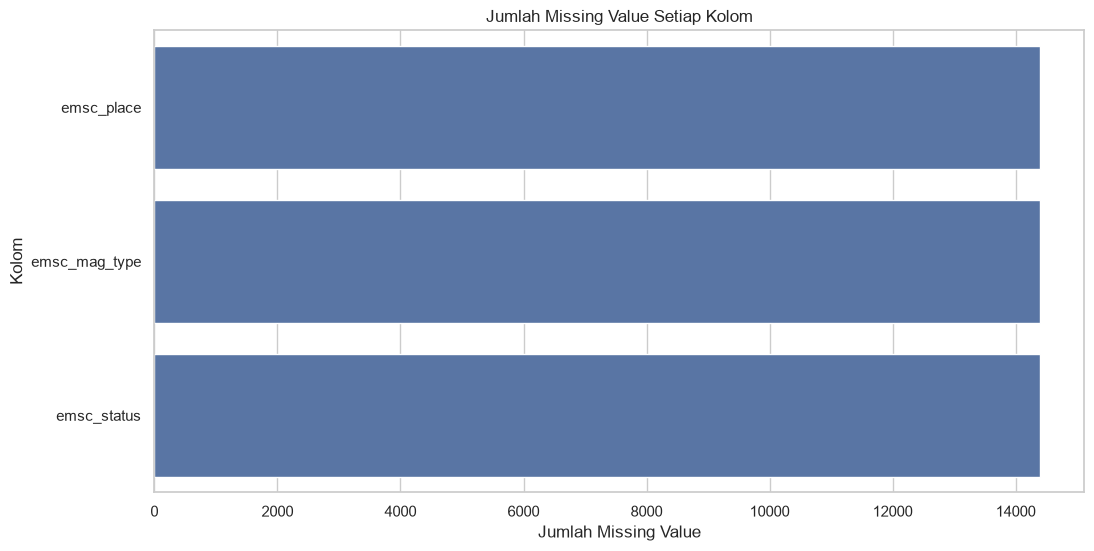

In [15]:
missing_plot = missing_table[
    missing_table["Jumlah Missing"] > 0
].sort_values(
    "Jumlah Missing",
    ascending=False
)

plt.figure(figsize=(12, 6))

if len(missing_plot) > 0:
    sns.barplot(
        data=missing_plot,
        x="Jumlah Missing",
        y="Kolom"
    )

    plt.title("Jumlah Missing Value Setiap Kolom")
    plt.xlabel("Jumlah Missing Value")
    plt.ylabel("Kolom")
    plt.show()
else:
    plt.text(
        0.5,
        0.5,
        "Tidak terdapat missing value",
        ha="center",
        va="center",
        fontsize=16
    )

    plt.axis("off")
    plt.show()

# Mengecek Duplikat

In [16]:
duplicate_count = df.duplicated().sum()

print("Jumlah data duplikat:", duplicate_count)

duplicate_percentage = (
    duplicate_count / len(df) * 100
)

print(
    f"Persentase data duplikat: "
    f"{duplicate_percentage:.2f}%"
)

Jumlah data duplikat: 0
Persentase data duplikat: 0.00%


# Mengecek Tipe Data

In [18]:
dtype_table = pd.DataFrame({
    "Kolom": df.columns,
    "Tipe Data": df.dtypes.astype(str).values
})

dtype_table

,Kolom,Tipe Data
0,usgs_id,str
1,event_time,datetime64[us]
2,magnitude,float64
3,place,str
4,depth_km,float64
5,longitude,float64
6,latitude,float64
7,mag_type,str
8,status,str
9,tsunami,int64


# Mengecek Nilai Unik

In [19]:
for column in df.select_dtypes(include="object").columns:
    print("=" * 60)
    print(f"Kolom: {column}")
    print(df[column].value_counts().head(10))

Kolom: usgs_id
usgs_id
ak025cmx1d48    1
ak025cwudqus    1
ak025d517bzx    1
ak025d59j5t5    1
ak025d8cqrw0    1
ak025dnijfwa    1
ak025dxe5mlz    1
ak025e5h93e7    1
ak025eiudryl    1
ak2025wzudcl    1
Name: count, dtype: int64
Kolom: place
place
south of the Fiji Islands        320
South Sandwich Islands region    277
Fiji region                      183
south of the Kermadec Islands    176
Kermadec Islands region          168
Mid-Indian Ridge                 122
Izu Islands, Japan region        101
southern Mid-Atlantic Ridge       96
Kermadec Islands, New Zealand     76
Kuril Islands                     69
Name: count, dtype: int64
Kolom: mag_type
mag_type
mb     12492
mww     1414
mwr      325
ml        98
mw        38
md        27
mwb        3
Name: count, dtype: int64
Kolom: status
status
reviewed    14397
Name: count, dtype: int64
Kolom: emsc_id
emsc_id
20260402_0000725    3
20260815_0000947    3
20260509_0000058    2
20251010_0000405    2
20251018_0000194    2
20251029_0000165

# Mengecek Nilai Tidak Valid

In [20]:
print(
    "Latitude tidak valid:",
    (
        (df["latitude"] < -90) |
        (df["latitude"] > 90)
    ).sum()
)

print(
    "Longitude tidak valid:",
    (
        (df["longitude"] < -180) |
        (df["longitude"] > 180)
    ).sum()
)

print(
    "Magnitudo <= 0:",
    (df["magnitude"] <= 0).sum()
)

print(
    "Kedalaman < 0:",
    (df["depth_km"] < 0).sum()
)

Latitude tidak valid: 0
Longitude tidak valid: 0
Magnitudo <= 0: 0
Kedalaman < 0: 0


# Mengecek Rentang Variabel

In [21]:
numeric_columns = [
    "magnitude",
    "depth_km",
    "latitude",
    "longitude",
    "distance_km",
    "temperature_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean"
]

range_table = pd.DataFrame({
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max(),
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median()
})

range_table

,Minimum,Maximum,Mean,Median
magnitude,4.0000,7.800000,4.548110,4.500000
depth_km,1.4160,683.578000,81.634897,28.747000
latitude,-84.4932,86.141400,6.956882,4.569500
longitude,-179.9993,179.999400,47.656280,120.473700
distance_km,0.0000,49.919427,7.295316,4.178833
temperature_2m_mean,-48.3000,40.800000,18.366667,23.000000
precipitation_sum,0.0000,188.800000,4.431152,0.800000
wind_speed_10m_max,2.4000,110.100000,28.093026,25.600000
surface_pressure_mean,439.6000,1047.600000,977.465444,1010.100000


## Insight Setelah Assessing Data

Berdasarkan proses assessment dilakukan pemeriksaan terhadap :

- struktur dataset;
- jumlah baris dan kolom;
- tipe data;
- statistik deskriptif;
- missing value;
- data duplikat;
- nilai unik;
- rentang nilai;
- validitas koordinat;
- validitas magnitudo dan kedalaman.

Tahap assessment dilakukan sebelum proses cleaning agar kondisi awal dataset
dapat diketahui dan keputusan pembersihan data dapat dilakukan berdasarkan
hasil pemeriksaan.

# Cleaning Data

In [22]:
df_clean = df.copy()

print("Ukuran dataset sebelum cleaning:", df_clean.shape)

Ukuran dataset sebelum cleaning: (14397, 28)


# Mengubah Tipe Waktu

In [24]:
df_clean["event_time"] = pd.to_datetime(
    df_clean["event_time"],
    errors="coerce"
)

print(df_clean["event_time"].dtype)

datetime64[us]


# Menghapus Duplikat

In [25]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates()

after = len(df_clean)

print("Data sebelum cleaning :", before)
print("Data setelah cleaning  :", after)
print("Duplikat dihapus       :", before - after)

Data sebelum cleaning : 14397
Data setelah cleaning  : 14397
Duplikat dihapus       : 0


# Menangani Nilai Tidak Valid

In [26]:
df_clean = df_clean[
    df_clean["latitude"].between(-90, 90)
]

df_clean = df_clean[
    df_clean["longitude"].between(-180, 180)
]

df_clean = df_clean[
    df_clean["magnitude"] > 0
]

df_clean = df_clean[
    df_clean["depth_km"] >= 0
]

df_clean = df_clean.reset_index(drop=True)

print("Ukuran dataset setelah validasi:", df_clean.shape)

Ukuran dataset setelah validasi: (14397, 28)


# Memeriksa Missing Setelah Cleaning

In [27]:
df_clean.isna().sum()

usgs_id                      0
event_time                   0
magnitude                    0
place                        0
depth_km                     0
longitude                    0
latitude                     0
mag_type                     0
status                       0
tsunami                      0
emsc_id                      0
emsc_event_time              0
emsc_magnitude               0
emsc_place               14397
emsc_depth_km                0
emsc_longitude               0
emsc_latitude                0
emsc_mag_type            14397
emsc_status              14397
distance_km                  0
magnitude_diff               0
event_date                   0
weather_lat                  0
weather_lon                  0
temperature_2m_mean          0
precipitation_sum            0
wind_speed_10m_max           0
surface_pressure_mean        0
dtype: int64

## Insight Setelah Cleaning

Setelah proses cleaning dilakukan dataset diperiksa kembali untuk memastikan
bahwa data yang digunakan dalam analisis memiliki struktur dan nilai yang sesuai.

Data duplikat dihapus agar satu kejadian tidak dihitung lebih dari satu kali.
Koordinat geografis dibatasi pada rentang yang valid sedangkan nilai magnitudo dan kedalaman yang tidak valid dikeluarkan.

Dataset hasil cleaning selanjutnya digunakan untuk feature engineering,
EDA, analisis pertanyaan bisnis dan pemodelan Machine Learning.

# Feature Engineering

In [28]:
df_clean["year"] = df_clean["event_time"].dt.year
df_clean["month"] = df_clean["event_time"].dt.month
df_clean["day"] = df_clean["event_time"].dt.day
df_clean["hour"] = df_clean["event_time"].dt.hour
df_clean["day_of_week"] = df_clean["event_time"].dt.dayofweek

df_clean.head()

,usgs_id,event_time,magnitude,place,depth_km,longitude,latitude,mag_type,status,tsunami,emsc_id,emsc_event_time,emsc_magnitude,emsc_place,emsc_depth_km,emsc_longitude,emsc_latitude,emsc_mag_type,emsc_status,distance_km,magnitude_diff,event_date,weather_lat,weather_lon,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,surface_pressure_mean,year,month,day,hour,day_of_week
0,ak025cmx1d48,2025-10-02 07:13:49,4.6,"57 km W of Karluk, Alaska",3.9,-155.4025,57.6300,ml,reviewed,0,20251002_0000111,2025-10-02 07:13:49,4.6,None,-4.1,-155.4223,57.6579,None,None,3.318562,0.0,2025-10-02,57.6,-155.4,9.4,6.7,42.9,1001.9,2025,10,2,7,3
1,ak025cwudqus,2025-10-08 07:33:56,4.0,"52 km WNW of Nanwalek, Alaska",94.0,-152.8125,59.4909,ml,reviewed,0,20251008_0000106,2025-10-08 07:33:55,4.0,None,-99.0,-152.8084,59.4943,None,None,0.443277,0.0,2025-10-08,59.5,-152.8,10.7,0.0,18.5,1014.9,2025,10,8,7,2
2,ak025d517bzx,2025-10-13 02:52:31,4.2,"30 km ESE of Kasilof, Alaska",45.9,-150.7827,60.2202,ml,reviewed,0,20251013_0000039,2025-10-13 02:52:30,4.4,None,-35.0,-150.7358,60.1803,None,None,5.138202,0.2,2025-10-13,60.2,-150.8,8.5,9.4,5.9,998.7,2025,10,13,2,0
3,ak025d59j5t5,2025-10-13 16:51:17,4.1,"33 km E of Port Alsworth, Alaska",188.4,-153.7065,60.1979,ml,reviewed,0,20251013_0000227,2025-10-13 16:51:16,4.1,None,-185.5,-153.8712,60.2235,None,None,9.533415,0.0,2025-10-13,60.2,-153.7,5.2,12.8,9.1,950.8,2025,10,13,16,0
4,ak025d8cqrw0,2025-10-15 03:30:45,4.0,"13 km SE of Glacier View, Alaska",27.0,-147.4562,61.7294,ml,reviewed,0,20251015_0000061,2025-10-15 03:30:45,4.0,None,-35.9,-147.5121,61.7506,None,None,3.770722,0.0,2025-10-15,61.7,-147.5,-4.9,0.6,8.3,850.6,2025,10,15,3,2


# Kategori Kedalaman

In [29]:
def depth_category(depth):
    if depth < 70:
        return "Dangkal"
    elif depth < 300:
        return "Menengah"
    else:
        return "Dalam"

df_clean["depth_category"] = (
    df_clean["depth_km"]
    .apply(depth_category)
)

df_clean["depth_category"].value_counts()

depth_category
Dangkal     10309
Menengah     3033
Dalam        1055
Name: count, dtype: int64

# Kategori Magnitudo

In [30]:
def magnitude_category(magnitude):
    if magnitude < 5:
        return "Rendah"
    elif magnitude < 6:
        return "Sedang"
    elif magnitude < 7:
        return "Kuat"
    else:
        return "Sangat Kuat"

df_clean["magnitude_category"] = (
    df_clean["magnitude"]
    .apply(magnitude_category)
)

df_clean["magnitude_category"].value_counts()

magnitude_category
Rendah         12431
Sedang          1831
Kuat             121
Sangat Kuat       14
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

Tahap Exploratory Data Analysis dilakukan untuk memahami pola, distribusi,
hubungan antarvariabel serta karakteristik kejadian gempa berdasarkan
empat pertanyaan bisnis yang telah ditentukan.

# Distribusi Magnitudo

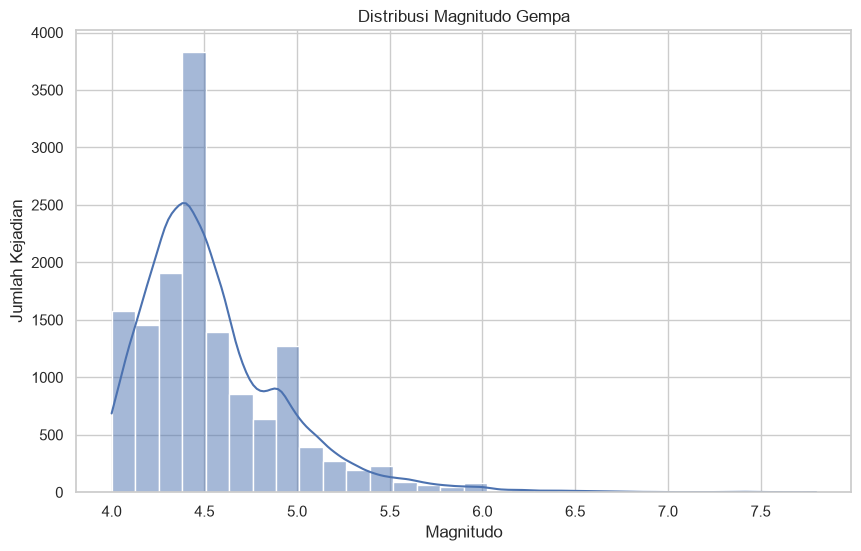

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="magnitude",
    bins=30,
    kde=True
)

plt.title("Distribusi Magnitudo Gempa")
plt.xlabel("Magnitudo")
plt.ylabel("Jumlah Kejadian")
plt.show()

# Boxplot Magnitudo

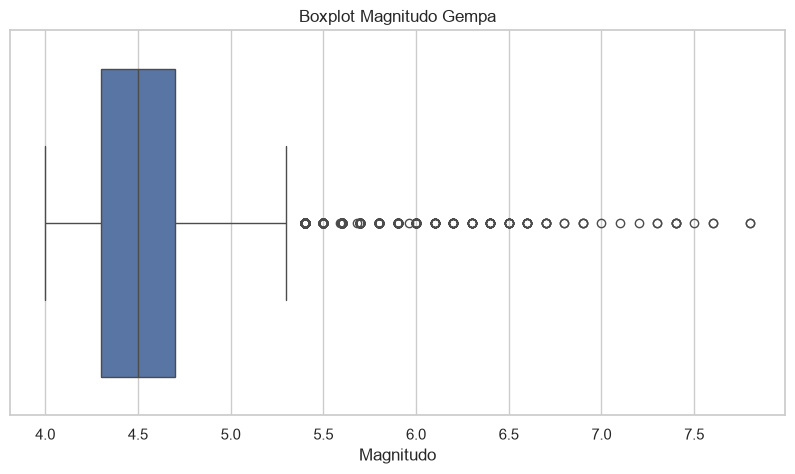

In [32]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df_clean["magnitude"]
)

plt.title("Boxplot Magnitudo Gempa")
plt.xlabel("Magnitudo")
plt.show()

# Distribusi Kedalaman

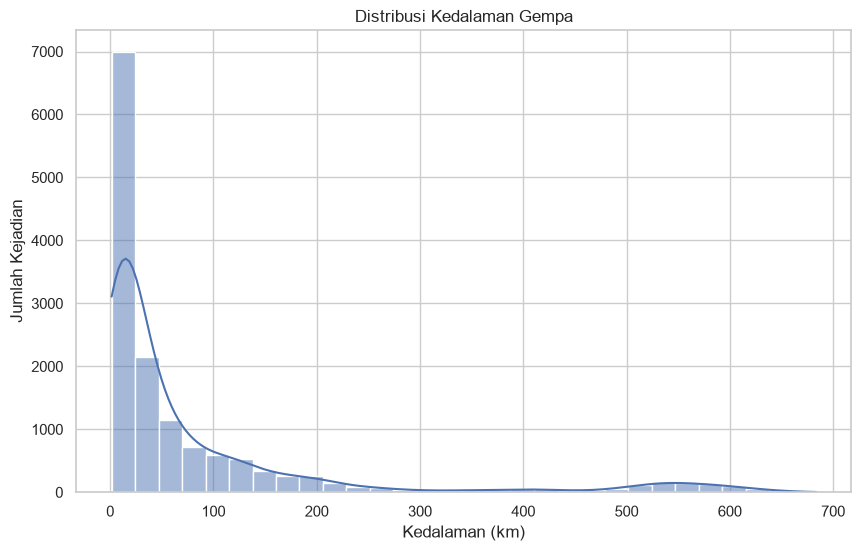

In [33]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="depth_km",
    bins=30,
    kde=True
)

plt.title("Distribusi Kedalaman Gempa")
plt.xlabel("Kedalaman (km)")
plt.ylabel("Jumlah Kejadian")
plt.show()

# Magnitudo Berdasarkan Kedalaman

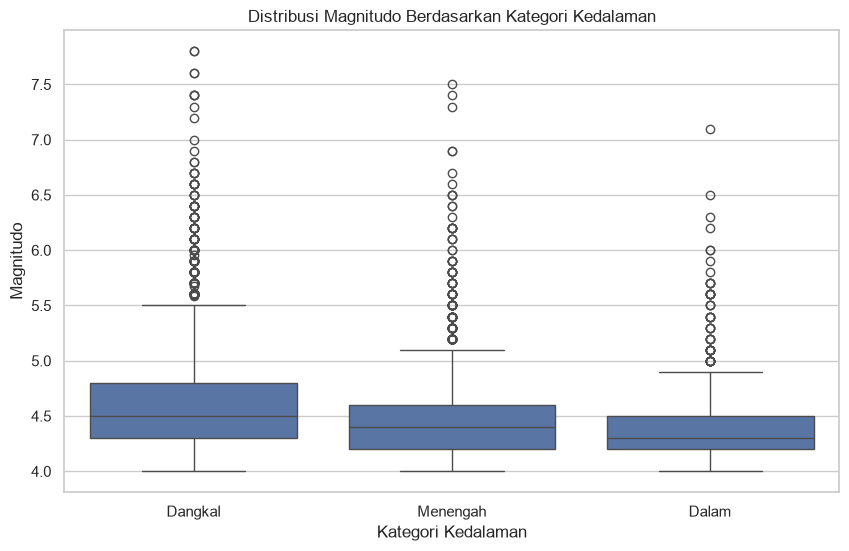

In [34]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="depth_category",
    y="magnitude"
)

plt.title(
    "Distribusi Magnitudo Berdasarkan "
    "Kategori Kedalaman"
)

plt.xlabel("Kategori Kedalaman")
plt.ylabel("Magnitudo")

plt.show()

# Jumlah Gempa per Tahun

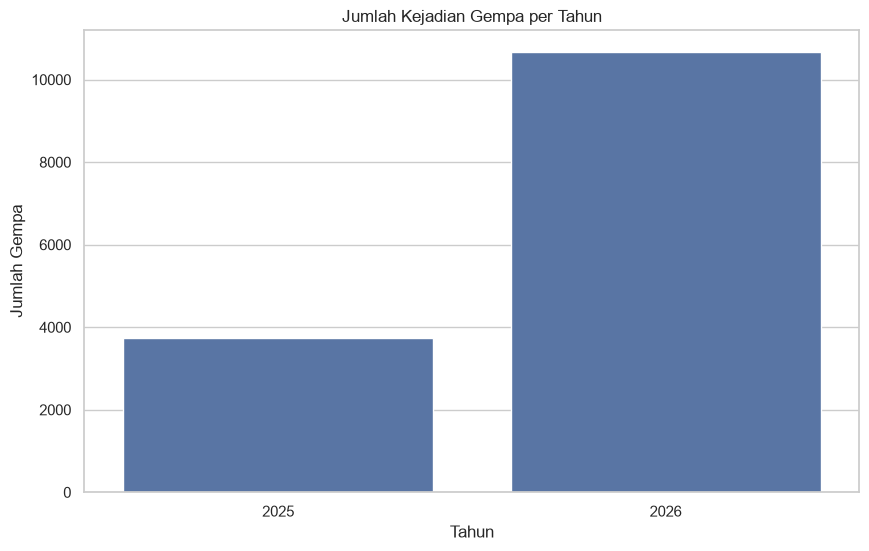

In [35]:
yearly = (
    df_clean
    .groupby("year")
    .size()
    .reset_index(name="jumlah_gempa")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=yearly,
    x="year",
    y="jumlah_gempa"
)

plt.title("Jumlah Kejadian Gempa per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Gempa")

plt.show()

# Jumlah Gempa per Bulan

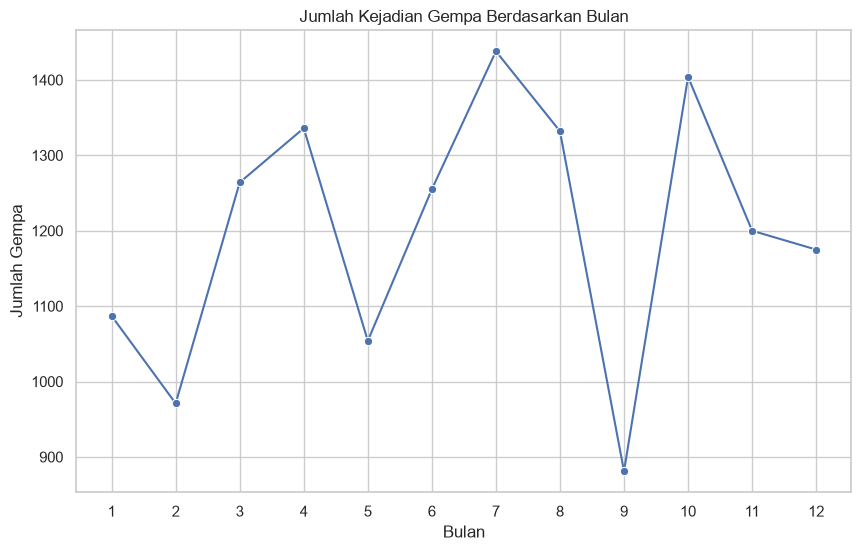

In [36]:
monthly = (
    df_clean
    .groupby("month")
    .size()
    .reset_index(name="jumlah_gempa")
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly,
    x="month",
    y="jumlah_gempa",
    marker="o"
)

plt.title("Jumlah Kejadian Gempa Berdasarkan Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Gempa")
plt.xticks(range(1, 13))

plt.show()

# Jumlah Gempa per Jam

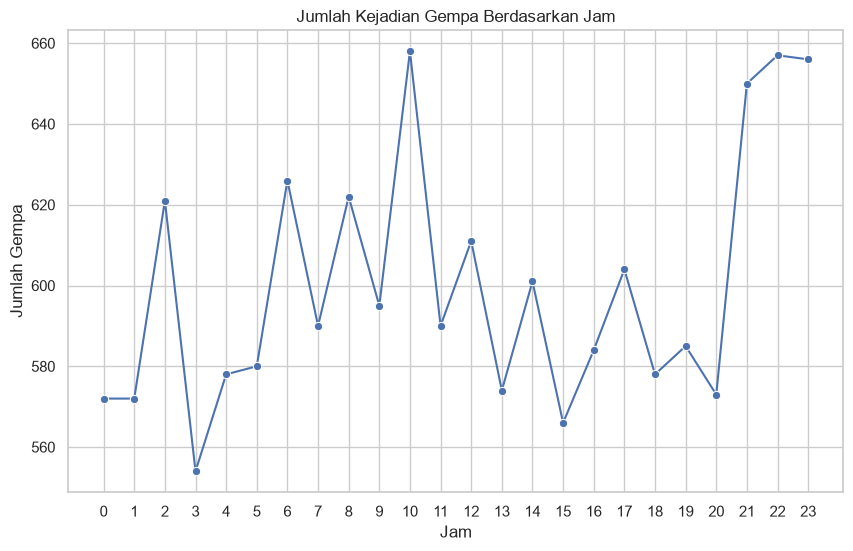

In [37]:
hourly = (
    df_clean
    .groupby("hour")
    .size()
    .reset_index(name="jumlah_gempa")
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=hourly,
    x="hour",
    y="jumlah_gempa",
    marker="o"
)

plt.title("Jumlah Kejadian Gempa Berdasarkan Jam")
plt.xlabel("Jam")
plt.ylabel("Jumlah Gempa")
plt.xticks(range(0, 24))

plt.show()

# Pertanyaan Bisnis 1

## Bagaimana karakteristik kejadian gempa berdasarkan magnitudo, kedalaman dan periode waktu?

Analisis dilakukan menggunakan distribusi magnitudo, distribusi kedalaman,
jumlah kejadian berdasarkan tahun, bulan dan jam.

# Statistik Pertanyaan 1

In [38]:
print("Statistik Magnitudo")
print("=" * 40)

print(
    df_clean["magnitude"]
    .describe()
)

Statistik Magnitudo
count    14397.000000
mean         4.548110
std          0.400463
min          4.000000
25%          4.300000
50%          4.500000
75%          4.700000
max          7.800000
Name: magnitude, dtype: float64


In [39]:
print("Statistik Kedalaman")
print("=" * 40)

print(
    df_clean["depth_km"]
    .describe()
)

Statistik Kedalaman
count    14397.000000
mean        81.634897
std        135.566422
min          1.416000
25%         10.000000
50%         28.747000
75%         83.948000
max        683.578000
Name: depth_km, dtype: float64


# Insight Pertanyaan 1

In [41]:
most_common_magnitude = (
    df_clean["magnitude_category"]
    .value_counts()
    .idxmax()
)

highest_year = yearly.loc[
    yearly["jumlah_gempa"].idxmax(),
    "year"
]

highest_month = monthly.loc[
    monthly["jumlah_gempa"].idxmax(),
    "month"
]

highest_hour = hourly.loc[
    hourly["jumlah_gempa"].idxmax(),
    "hour"
]

print(
    "Kategori magnitudo terbanyak:",
    most_common_magnitude
)

print(
    "Tahun dengan kejadian terbanyak:",
    highest_year
)

print(
    "Bulan dengan kejadian terbanyak:",
    highest_month
)

print(
    "Jam dengan kejadian terbanyak:",
    highest_hour
)

Kategori magnitudo terbanyak: Rendah
Tahun dengan kejadian terbanyak: 2026
Bulan dengan kejadian terbanyak: 7
Jam dengan kejadian terbanyak: 10


# Pertanyaan Bisnis 2

## Bagaimana hubungan antara magnitudo gempa dengan kedalaman serta kondisi cuaca pada lokasi kejadian gempa?

# Kedalaman vs Magnitudo

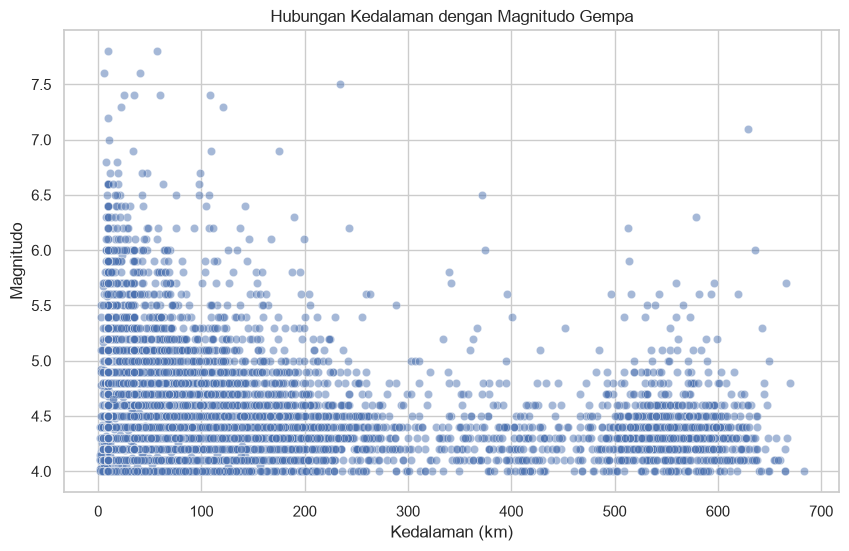

In [42]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="depth_km",
    y="magnitude",
    alpha=0.5
)

plt.title(
    "Hubungan Kedalaman dengan Magnitudo Gempa"
)

plt.xlabel("Kedalaman (km)")
plt.ylabel("Magnitudo")

plt.show()

# Temperatur vs Magnitudo

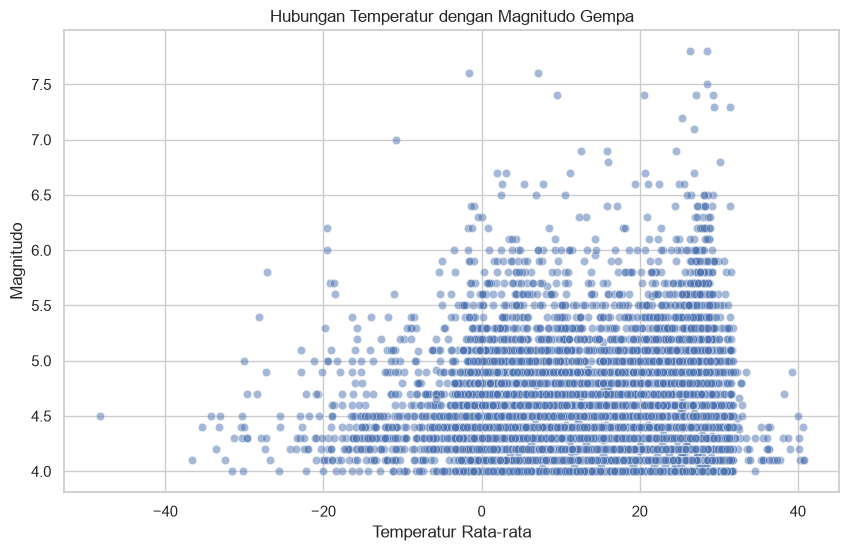

In [43]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="temperature_2m_mean",
    y="magnitude",
    alpha=0.5
)

plt.title(
    "Hubungan Temperatur dengan Magnitudo Gempa"
)

plt.xlabel("Temperatur Rata-rata")
plt.ylabel("Magnitudo")

plt.show()

# Angin vs Magnitudo

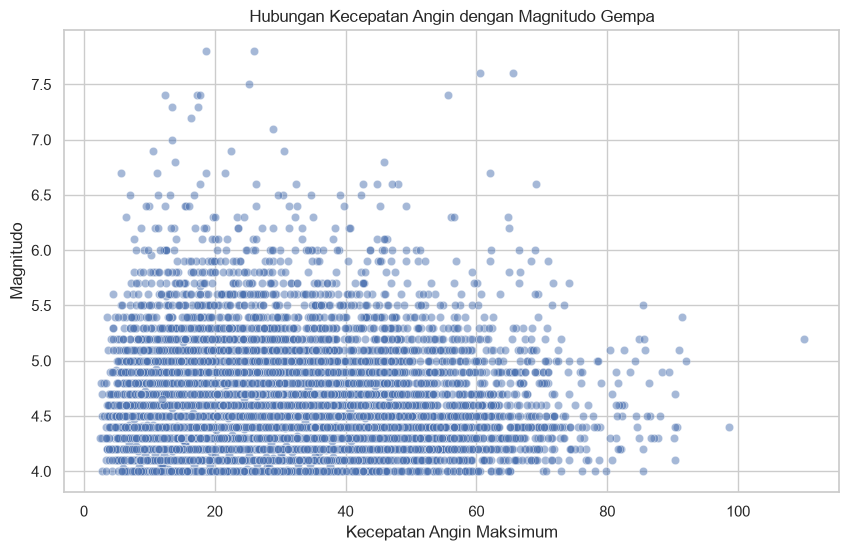

In [45]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="wind_speed_10m_max",
    y="magnitude",
    alpha=0.5
)

plt.title(
    "Hubungan Kecepatan Angin dengan Magnitudo Gempa"
)

plt.xlabel("Kecepatan Angin Maksimum")
plt.ylabel("Magnitudo")

plt.show()

# Curah Hujan vs Magnitudo

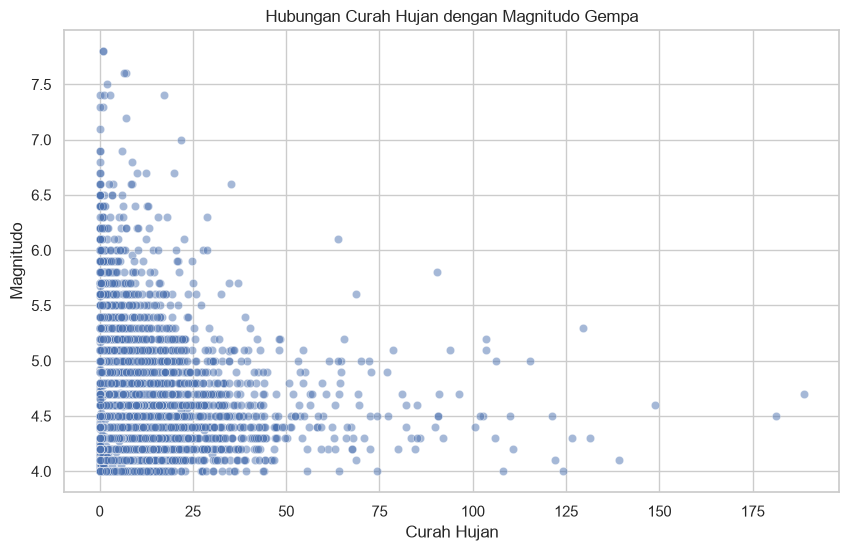

In [47]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="precipitation_sum",
    y="magnitude",
    alpha=0.5
)

plt.title(
    "Hubungan Curah Hujan dengan Magnitudo Gempa"
)

plt.xlabel("Curah Hujan")
plt.ylabel("Magnitudo")

plt.show()

# Correlation Matrix

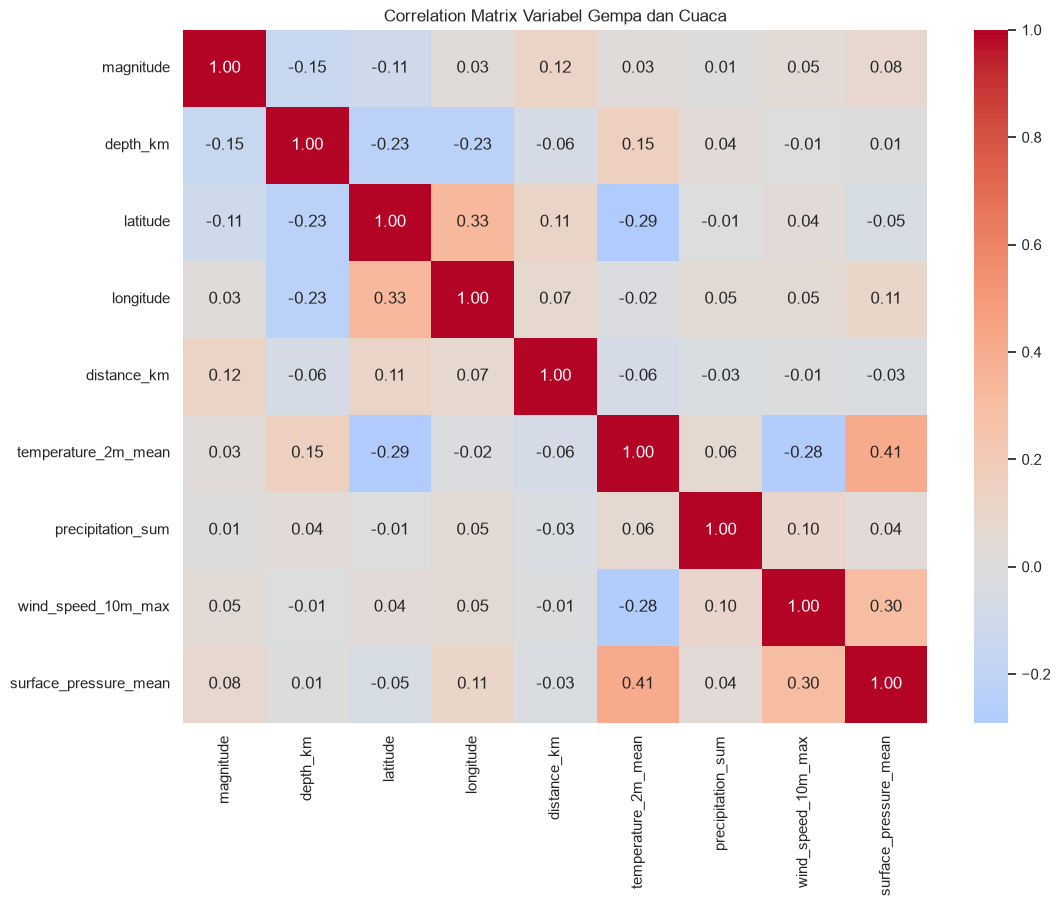

In [48]:
correlation_columns = [
    "magnitude",
    "depth_km",
    "latitude",
    "longitude",
    "distance_km",
    "temperature_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean"
]

correlation = (
    df_clean[correlation_columns]
    .corr()
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix Variabel Gempa dan Cuaca"
)

plt.show()

# Korelasi terhadap Magnitudo

In [49]:
magnitude_correlation = (
    correlation["magnitude"]
    .sort_values(
        ascending=False
    )
)

magnitude_correlation

magnitude                1.000000
distance_km              0.120238
surface_pressure_mean    0.079920
wind_speed_10m_max       0.045639
longitude                0.029902
temperature_2m_mean      0.029370
precipitation_sum        0.013975
latitude                -0.105507
depth_km                -0.150835
Name: magnitude, dtype: float64

# Insight Pertanyaan 2

In [50]:
correlation_without_target = (
    magnitude_correlation
    .drop("magnitude")
)

strongest_feature = (
    correlation_without_target
    .abs()
    .idxmax()
)

strongest_value = (
    correlation_without_target[strongest_feature]
)

print(
    "Variabel dengan hubungan linear terkuat terhadap magnitudo:"
)

print(
    strongest_feature,
    "=",
    round(strongest_value, 4)
)

Variabel dengan hubungan linear terkuat terhadap magnitudo:
depth_km = -0.1508


### Insight

Berdasarkan correlation matrix hubungan antarvariabel dianalisis untuk
mengetahui pola linear antara magnitudo dan karakteristik gempa maupun
variabel cuaca.

Nilai korelasi digunakan sebagai salah satu pertimbangan dalam memahami
hubungan antarvariabel tetapi tidak digunakan sebagai satu-satunya dasar
dalam menentukan fitur Machine Learning.

# Pertanyaan Bisnis 3

## Wilayah atau lokasi mana yang memiliki konsentrasi kejadian gempa paling tinggi?

# Top Lokasi

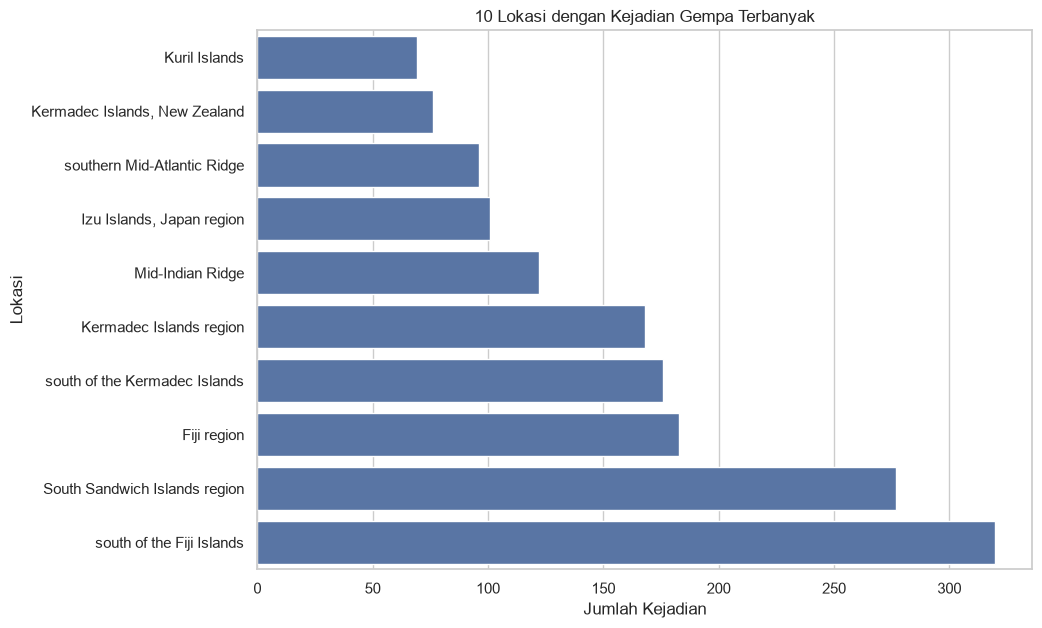

In [51]:
top_places = (
    df_clean["place"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_places.values,
    y=top_places.index
)

plt.title(
    "10 Lokasi dengan Kejadian Gempa Terbanyak"
)

plt.xlabel("Jumlah Kejadian")
plt.ylabel("Lokasi")

plt.show()

# Peta Sebaran Gempa

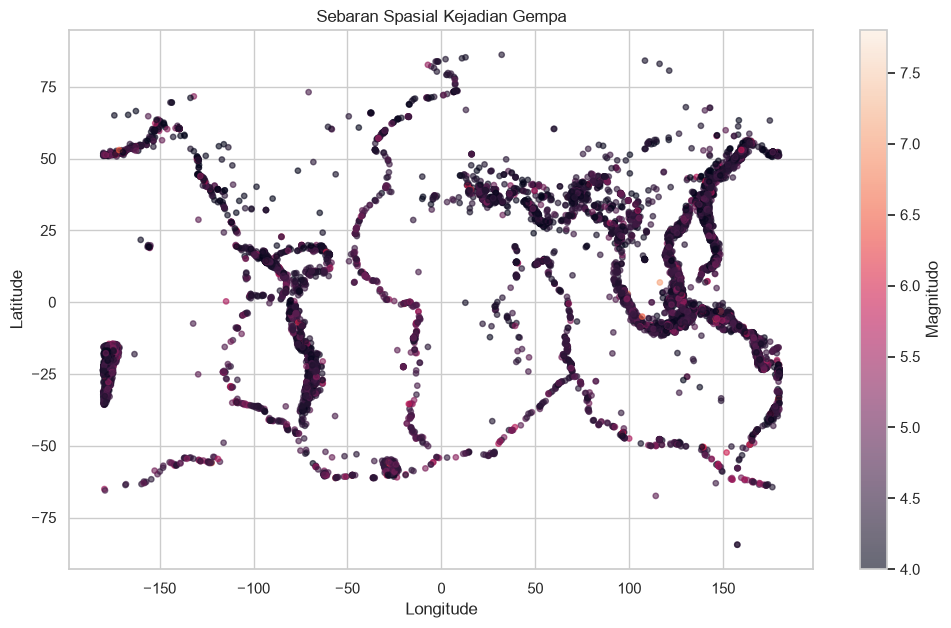

In [52]:
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    df_clean["longitude"],
    df_clean["latitude"],
    c=df_clean["magnitude"],
    s=15,
    alpha=0.6
)

plt.colorbar(
    scatter,
    label="Magnitudo"
)

plt.title(
    "Sebaran Spasial Kejadian Gempa"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

# Lokasi dengan Rata-rata Magnitudo Tertinggi

In [53]:
location_summary = (
    df_clean
    .groupby("place")
    .agg(
        jumlah_gempa=("magnitude", "count"),
        rata_rata_magnitudo=("magnitude", "mean"),
        maksimum_magnitudo=("magnitude", "max")
    )
    .sort_values(
        "jumlah_gempa",
        ascending=False
    )
)

location_summary.head(10)

,jumlah_gempa,rata_rata_magnitudo,maksimum_magnitudo
place,,,
south of the Fiji Islands,320,4.458125,6.0
South Sandwich Islands region,277,4.721661,6.4
Fiji region,183,4.398361,6.3
south of the Kermadec Islands,176,4.634091,6.3
Kermadec Islands region,168,4.644643,5.9
Mid-Indian Ridge,122,4.614754,5.3
"Izu Islands, Japan region",101,4.509901,5.7
southern Mid-Atlantic Ridge,96,4.781250,5.9
"Kermadec Islands, New Zealand",76,4.677632,6.1


# Insight Pertanyaan 3

In [54]:
top_location = (
    df_clean["place"]
    .value_counts()
    .idxmax()
)

top_location_count = (
    df_clean["place"]
    .value_counts()
    .max()
)

print("Lokasi dengan jumlah kejadian terbanyak:")
print(top_location)

print("\nJumlah kejadian:")
print(top_location_count)

Lokasi dengan jumlah kejadian terbanyak:
south of the Fiji Islands

Jumlah kejadian:
320


# Pertanyaan Bisnis 4 AI

## Seberapa baik model Machine Learning dapat memprediksi magnitudo gempa?

Pada tahap ini digunakan satu algoritma Machine Learning yaitu Random Forest Regressor.

Random Forest dipilih karena mampu menangani hubungan nonlinear,
interaksi antarfitur serta memiliki kemampuan untuk memberikan
informasi feature importance.

Target yang diprediksi adalah:

**magnitude**

# Menentukan Fitur

In [55]:
features = [
    "depth_km",
    "latitude",
    "longitude",
    "distance_km",
    "temperature_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean",
    "year",
    "month",
    "day",
    "hour",
    "day_of_week"
]

target = "magnitude"

X = df_clean[features].copy()
y = df_clean[target].copy()

print("Jumlah fitur:", len(features))
print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Jumlah fitur: 13
Ukuran X: (14397, 13)
Ukuran y: (14397,)


# Cek Missing Fitur

In [57]:
print("Missing value pada fitur:")
print(X.isna().sum())

print("\nMissing value target:")
print(y.isna().sum())

Missing value pada fitur:
depth_km                 0
latitude                 0
longitude                0
distance_km              0
temperature_2m_mean      0
precipitation_sum        0
wind_speed_10m_max       0
surface_pressure_mean    0
year                     0
month                    0
day                      0
hour                     0
day_of_week              0
dtype: int64

Missing value target:
0


# Menangani Missing untuk ML

In [58]:
model_data = pd.concat(
    [X, y],
    axis=1
).dropna()

X = model_data[features]
y = model_data[target]

print("Dataset untuk Machine Learning:")
print("X:", X.shape)
print("y:", y.shape)

Dataset untuk Machine Learning:
X: (14397, 13)
y: (14397,)


# Train Test Split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Data training :", len(X_train))
print("Data testing  :", len(X_test))

print("\nUkuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Data training : 11517
Data testing  : 2880

Ukuran X_train: (11517, 13)
Ukuran X_test : (2880, 13)
Ukuran y_train: (11517,)
Ukuran y_test : (2880,)


# Baseline Random Forest

In [60]:
baseline_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_pred = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("==========================================")
print("BASELINE RANDOM FOREST")
print("==========================================")
print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

BASELINE RANDOM FOREST
MAE  : 0.2295
RMSE : 0.3274
R²   : 0.3381


# Optimasi Random Forest

In [62]:
rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_distributions = {
    "n_estimators": [
        200,
        300,
        500,
        700,
        1000
    ],

    "max_depth": [
        None,
        10,
        15,
        20,
        25,
        30,
        40
    ],

    "min_samples_split": [
        2,
        3,
        5,
        8,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        3,
        4,
        5
    ],

    "max_features": [
        0.5,
        0.7,
        0.8,
        1.0
    ],

    "bootstrap": [
        True
    ]
}

# Cross Validation

In [63]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="r2",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Mulai proses optimasi...")

Mulai proses optimasi...


# Training Optimasi

In [64]:
random_search.fit(
    X_train,
    y_train
)

print("Optimasi selesai.")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Optimasi selesai.


# Parameter Terbaik

In [65]:
print("Parameter terbaik:")
print(random_search.best_params_)

print("\nCross-validation R² terbaik:")
print(
    f"{random_search.best_score_:.4f}"
)

Parameter terbaik:
{'n_estimators': 500, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 40, 'bootstrap': True}

Cross-validation R² terbaik:
0.3338


# Model Terbaik

In [66]:
best_model = random_search.best_estimator_

print(best_model)

RandomForestRegressor(max_depth=40, max_features=0.5, min_samples_leaf=4,
                      min_samples_split=8, n_estimators=500, n_jobs=-1,
                      random_state=42)


# Prediksi Model Optimized

In [67]:
y_pred = best_model.predict(X_test)

print("Prediksi berhasil dilakukan.")

Prediksi berhasil dilakukan.


# Evaluasi Model Final

In [68]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("==========================================")
print("HASIL EVALUASI RANDOM FOREST OPTIMIZED")
print("==========================================")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

HASIL EVALUASI RANDOM FOREST OPTIMIZED
MAE  : 0.2254
RMSE : 0.3241
R²   : 0.3513


# Perbandingan Baseline vs Optimized

In [69]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Optimized Random Forest"
    ],

    "MAE": [
        baseline_mae,
        mae
    ],

    "RMSE": [
        baseline_rmse,
        rmse
    ],

    "R2": [
        baseline_r2,
        r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Baseline Random Forest,0.229531,0.327415,0.338118
1,Optimized Random Forest,0.225427,0.324135,0.351315


# Visualisasi Perbandingan R²

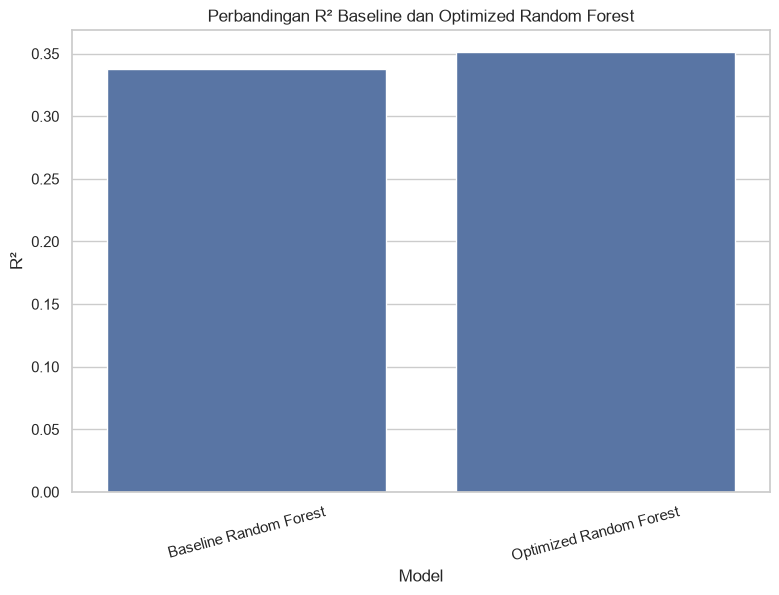

In [70]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2"
)

plt.title(
    "Perbandingan R² Baseline dan Optimized Random Forest"
)

plt.xlabel("Model")
plt.ylabel("R²")

plt.xticks(rotation=15)

plt.show()

# Actual vs Predicted

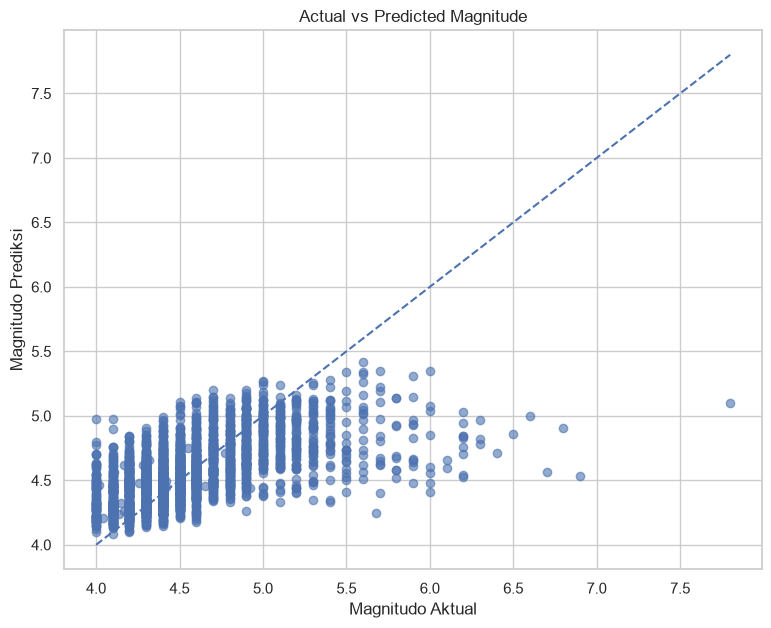

In [71]:
plt.figure(figsize=(9, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title(
    "Actual vs Predicted Magnitude"
)

plt.xlabel(
    "Magnitudo Aktual"
)

plt.ylabel(
    "Magnitudo Prediksi"
)

plt.show()

# Residual Analysis

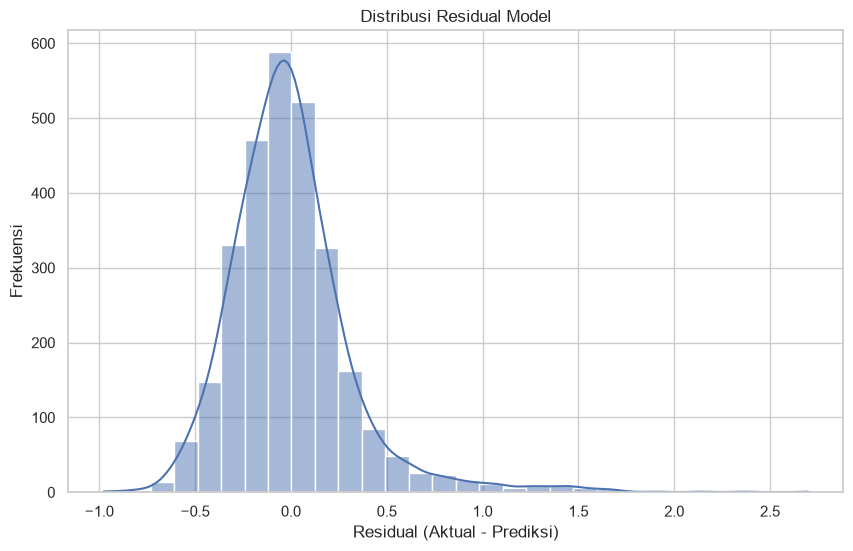

In [72]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title(
    "Distribusi Residual Model"
)

plt.xlabel(
    "Residual (Aktual - Prediksi)"
)

plt.ylabel(
    "Frekuensi"
)

plt.show()

# Residual vs Prediction

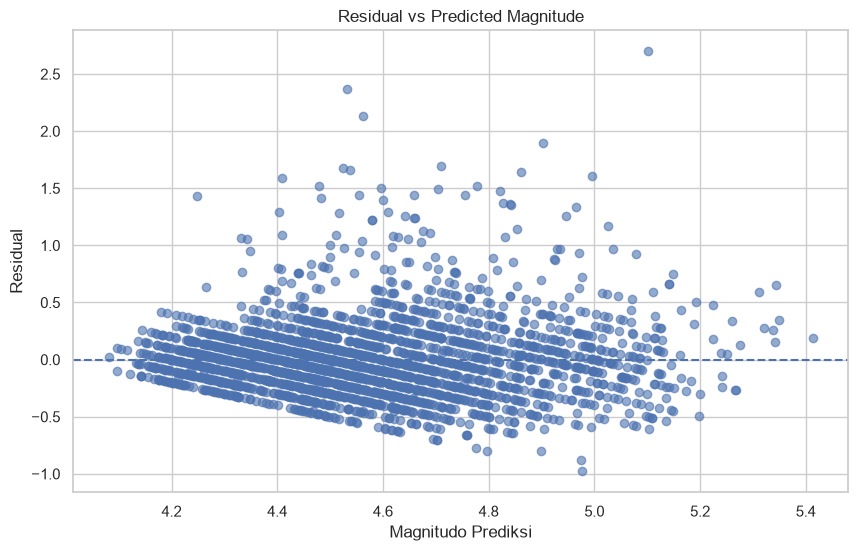

In [73]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Residual vs Predicted Magnitude"
)

plt.xlabel(
    "Magnitudo Prediksi"
)

plt.ylabel(
    "Residual"
)

plt.show()

# Feature Importance

In [74]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": best_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance

,Feature,Importance
0,distance_km,0.281878
1,latitude,0.134191
2,longitude,0.117036
3,depth_km,0.094054
4,surface_pressure_mean,0.068781
5,temperature_2m_mean,0.066337
6,wind_speed_10m_max,0.057580
7,hour,0.044732
8,precipitation_sum,0.042477
9,day,0.039797


# Visualisasi Feature Importance

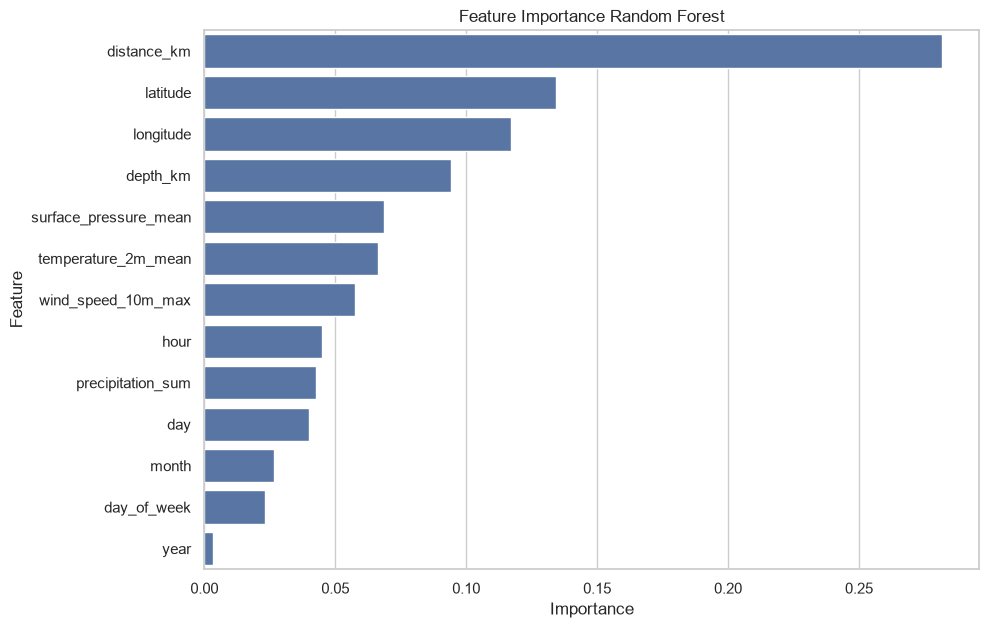

In [75]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# Fitur Paling Berpengaruh

In [76]:
top_feature = feature_importance.iloc[0]

print(
    "Fitur paling berpengaruh:",
    top_feature["Feature"]
)

print(
    "Importance:",
    round(
        top_feature["Importance"],
        4
    )
)

Fitur paling berpengaruh: distance_km
Importance: 0.2819


# Tabel Aktual dan Prediksi

In [77]:
prediction_result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_result["Error"] = (
    prediction_result["Actual"] -
    prediction_result["Predicted"]
)

prediction_result["Absolute_Error"] = (
    prediction_result["Error"].abs()
)

prediction_result.head(20)

,Actual,Predicted,Error,Absolute_Error
0,4.5,4.357424,0.142576,0.142576
1,4.6,4.646177,-0.046177,0.046177
2,4.1,4.686665,-0.586665,0.586665
3,4.5,4.853238,-0.353238,0.353238
4,4.3,4.190094,0.109906,0.109906
5,4.1,4.573423,-0.473423,0.473423
6,4.6,4.905214,-0.305214,0.305214
7,4.1,4.455809,-0.355809,0.355809
8,4.5,4.637266,-0.137266,0.137266
9,4.3,4.629591,-0.329591,0.329591


# Analisis Error

In [78]:
print(
    "Rata-rata absolute error:",
    prediction_result["Absolute_Error"].mean()
)

print(
    "Error terbesar:",
    prediction_result["Absolute_Error"].max()
)

print(
    "Error terkecil:",
    prediction_result["Absolute_Error"].min()
)

Rata-rata absolute error: 0.22542734028264585
Error terbesar: 2.6991362192905033
Error terkecil: 7.690898970480475e-05


# Ringkasan Hasil Model

In [79]:
print("==============================================")
print("RINGKASAN PERFORMA MODEL")
print("==============================================")

print(f"Baseline R²       : {baseline_r2:.4f}")
print(f"Optimized R²      : {r2:.4f}")
print(f"Optimized MAE     : {mae:.4f}")
print(f"Optimized RMSE    : {rmse:.4f}")
print(f"CV R²             : {random_search.best_score_:.4f}")

RINGKASAN PERFORMA MODEL
Baseline R²       : 0.3381
Optimized R²      : 0.3513
Optimized MAE     : 0.2254
Optimized RMSE    : 0.3241
CV R²             : 0.3338


# Interpretasi Performa

In [80]:
if r2 >= 0.90:
    performance = "sangat baik"
elif r2 >= 0.75:
    performance = "baik"
elif r2 >= 0.50:
    performance = "cukup baik"
elif r2 >= 0:
    performance = "masih terbatas"
else:
    performance = "belum mampu menjelaskan variasi target dengan baik"

print(
    f"Model memiliki performa {performance} "
    f"berdasarkan nilai R² sebesar {r2:.4f}."
)

Model memiliki performa masih terbatas berdasarkan nilai R² sebesar 0.3513.


# Analisis Lanjutan : Kategori Magnitudo

In [81]:
category_summary = (
    df_clean["magnitude_category"]
    .value_counts()
    .reset_index()
)

category_summary.columns = [
    "Kategori",
    "Jumlah"
]

category_summary

,Kategori,Jumlah
0,Rendah,12431
1,Sedang,1831
2,Kuat,121
3,Sangat Kuat,14


# Visualisasi Kategori Magnitudo

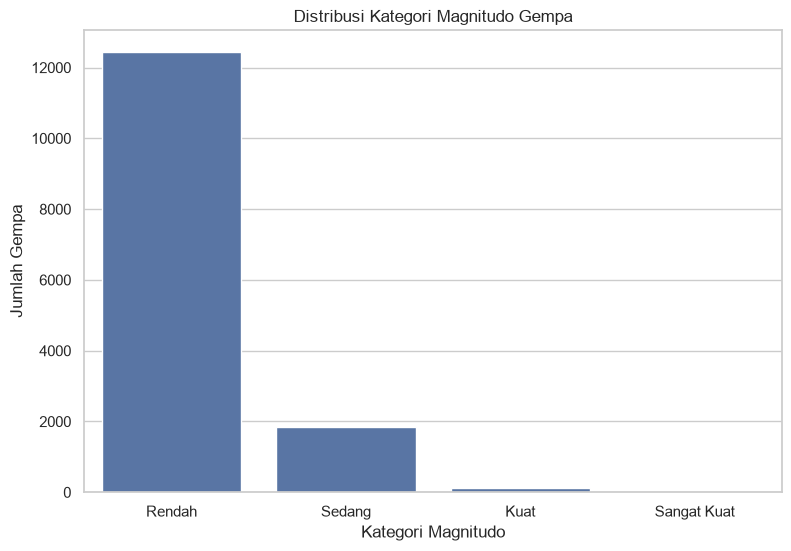

In [82]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=category_summary,
    x="Kategori",
    y="Jumlah"
)

plt.title(
    "Distribusi Kategori Magnitudo Gempa"
)

plt.xlabel("Kategori Magnitudo")
plt.ylabel("Jumlah Gempa")

plt.show()

# Ringkasan Dataset Final

In [83]:
summary = pd.DataFrame({
    "Informasi": [
        "Jumlah data awal",
        "Jumlah data setelah cleaning",
        "Jumlah fitur ML",
        "Jumlah data training",
        "Jumlah data testing",
        "MAE",
        "RMSE",
        "R²",
        "Cross Validation R²",
        "Fitur paling penting"
    ],

    "Nilai": [
        len(df),
        len(df_clean),
        len(features),
        len(X_train),
        len(X_test),
        round(mae, 4),
        round(rmse, 4),
        round(r2, 4),
        round(random_search.best_score_, 4),
        top_feature["Feature"]
    ]
})

summary

,Informasi,Nilai
0,Jumlah data awal,14397
1,Jumlah data setelah cleaning,14397
2,Jumlah fitur ML,13
3,Jumlah data training,11517
4,Jumlah data testing,2880
5,MAE,0.2254
6,RMSE,0.3241
7,R²,0.3513
8,Cross Validation R²,0.3338
9,Fitur paling penting,distance_km


# Conclusion

## Langkah-Langkah yang Telah Dilakukan

1. **Gathering Data**

   Data diperoleh dari tiga sumber API yaitu USGS Earthquake API,
   EMSC Earthquake API dan Open-Meteo Historical Weather API. Data tersebut dikumpulkan menggunakan pipeline ETL Apache Airflow  dan disimpan dalam database MySQL.

2. **Data Wrangling**

   Dataset diperiksa menggunakan `info()`, `describe()`, pemeriksaan
   missing value, data duplikat, tipe data, nilai unik serta validitas
   koordinat, magnitudo dan kedalaman.

3. **Cleaning Data**

   Data duplikat dan data yang tidak valid ditangani sehingga dataset
   lebih siap digunakan untuk proses analisis.

4. **Feature Engineering**

   Informasi waktu diubah menjadi fitur tahun, bulan, hari, jam dan hari dalam minggu. Selain itu dibuat kategori kedalaman dan kategori magnitudo.

5. **Exploratory Data Analysis**

   Analisis dilakukan menggunakan histogram, boxplot, bar chart,
   line chart, scatter plot, heatmap serta visualisasi spasial.

6. **Analisis Pertanyaan Bisnis**

   Empat pertanyaan bisnis dianalisis berdasarkan karakteristik gempa,
   hubungan antara gempa dan kondisi cuaca, distribusi spasial serta kemampuan Machine Learning dalam memprediksi magnitudo.

7. **Machine Learning**

   Random Forest Regressor digunakan sebagai satu-satunya algoritma
   Machine Learning sesuai ketentuan tugas.

8. **Optimasi Model**

   Hyperparameter Random Forest dioptimalkan menggunakan
   RandomizedSearchCV dengan 5-fold cross-validation untuk mendapatkan
   konfigurasi model yang memberikan performa terbaik pada data training.

9. **Evaluasi**

   Model dievaluasi menggunakan Mean Absolute Error (MAE),
   Root Mean Squared Error (RMSE) dan R².

10. **Feature Importance**

    Feature importance digunakan untuk mengetahui variabel yang paling
    berkontribusi terhadap prediksi magnitudo.

# Kesimpulan

In [85]:
print("======================================================")
print("KESIMPULAN HASIL ANALISIS")
print("======================================================")

print(
    f"Dataset akhir yang digunakan terdiri dari "
    f"{len(df_clean):,} baris."
)

print(
    f"Model Random Forest menghasilkan MAE sebesar "
    f"{mae:.4f}."
)

print(
    f"Model menghasilkan RMSE sebesar "
    f"{rmse:.4f}."
)

print(
    f"Model menghasilkan R² sebesar "
    f"{r2:.4f}."
)

print(
    f"Nilai cross-validation R² terbaik adalah "
    f"{random_search.best_score_:.4f}."
)

print(
    f"Fitur dengan importance tertinggi adalah "
    f"{top_feature['Feature']} "
    f"dengan nilai importance "
    f"{top_feature['Importance']:.4f}."
)

if r2 >= 0.90:
    print(
        "\nKesimpulan: model mencapai R² >= 0.90 "
        "sehingga mampu menjelaskan sebagian besar variasi "
        "magnitudo pada data pengujian."
    )

KESIMPULAN HASIL ANALISIS
Dataset akhir yang digunakan terdiri dari 14,397 baris.
Model Random Forest menghasilkan MAE sebesar 0.2254.
Model menghasilkan RMSE sebesar 0.3241.
Model menghasilkan R² sebesar 0.3513.
Nilai cross-validation R² terbaik adalah 0.3338.
Fitur dengan importance tertinggi adalah distance_km dengan nilai importance 0.2819.


In [86]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/random_forest_magnitude.pkl")
joblib.dump(features, "../models/model_features.pkl")

print("Model berhasil disimpan.")
print("Lokasi:", os.path.abspath("../models/random_forest_magnitude.pkl"))

Model berhasil disimpan.
Lokasi: c:\Users\Anissa\earthquake_data_science\models\random_forest_magnitude.pkl
